# Lab 1: Gradient descent

**Report by Ugo Roccamatisi.**


## 1. The quadratic case
 
We first apply the method to a quadratic functional:
\begin{align}\label{quadf}\tag{1} f(x)=\dfrac12 x^TA x + b^T x +c,\qquad \text{for } x\in \mathbb{R}^ N, \end{align}
with
$A$ a real symmetric positive-definite $N\times N$ matrix, $b\in\mathbb{R}^N$ and $c\in \mathbb{R}$. 

**Question 1.** Compute the gradient and the Hessian matrix of $f$.

**Question 2.** Deduce that $f$ is $\gamma$-convex.

**Question 3.** Show that $f$ reaches its minimum on $\mathbb{R}^N$ at a single point $x^*$. Give a characterization of this point. 

**Answers 1 to 3.** Since $A=A^T$, $\nabla f(x)=Ax+b$ and $\nabla^2 f(x)=A$. For $\gamma=\lambda_{\min}(A)>0$, we have $A\succeq\gamma I$: $f$ is therefore strongly convex and coercive. Its unique minimizer satisfies $Ax^*+b=0$, i.e. $x^*=-A^{-1}b$; the minimum value is $c-\frac12 b^TA^{-1}b$.

### 1.1 Gradient descent with optimal step

Let $f$ be a convex, coercive $C^1$ function on $\mathbb{R}^N$. Gradient descent with optimal step is defined as follows. 

Let $x^0\in \mathbb{R}^N$ (we try to choose $x^0$ close to $x^*$; without any information, we take $x^0=0$). 

Then, for $k=0,1,2,\ldots\ $ until convergence, repeat: 

$$
\left|
\begin{array}{lcl}
d^k& \longleftarrow & -\nabla f(x^k),\\
\alpha_k &\longleftarrow &\mathop{argmin}_{t>0} f(x^k + td^k),\\ 
x^{k+1}&\longleftarrow &x^k+\alpha_k d^k
\end{array}
\right.
$$

**Question 4.** Propose a stopping criterion for the algorithm based on the characterization of question **3**. 

**Remark:** In general, $\alpha_k$ cannot be computed exactly and in practice the second step is replaced by an approximate search. However, when $f$ is quadratic, computing $\alpha_k$ is "easy". 

__Solution 4.__ From question __3__, we want $\|\nabla f(x^k)\|$ to be as small as possible. A reasonable criterion is the following: given a (small) tolerance $\varepsilon>0$, stop the algorithm as soon as 

$$
\|\nabla f(x^k)\|\le\varepsilon\|\nabla f(x^0)\|.
$$

In other words, the algorithm stops once $\|\nabla f(x^k)\|$ has been reduced by at least a factor $\varepsilon$.

**Question 5.** For the quadratic function (1), express $d^k$ and $\alpha_k$ as functions of $A$, $x^k$ and $b$. 

At step $k$, we look for the $t$ minimizing $h(t):=f(x^k+td^k)$. Let $x=x^k$, $d=d^k$ and $g=\nabla f(x^k)= Ax^k+b$. We compute
$$
\qquad\quad h(t):= h(0) +  (d\!\cdot\! g)\,t+ \dfrac12 (d^TAd)\,t^2. 
$$
This is a degree-2 polynomial with leading coefficient $(d^TAd)/2>0$. It is minimal at the point $t$ where $h'(t)$ vanishes. We have

$$
h'(t)=0\ \iff\ (d\!\cdot\! g)+(d^TAd)\,t=0\ \iff\ t=-\dfrac{d\!\cdot\! g}{d^TAd}.
$$

We therefore choose
$$
\alpha_k:=-\dfrac{d^k\!\cdot\! g^k}{d^k\!\cdot\!(Ad^k)}.
$$

Hence $d^k=-(Ax^k+b)$ and, if $g^k\neq0$, $\alpha_k=\|g^k\|_2^2/(g^k{}^TAg^k)$. If $g^k=0$, we are already at the minimizer and stop.


We now set $N=2$ and
$$ A=\binom{C\quad 0}{0\quad 1},\quad C\ge 1,\quad b=0,\quad c=0.$$
**Question 6.** What is the infimum of $f$ on $\mathbb{R}^2$ in this case? Give $x^*$. 

__Answer 6.__ The infimum is $0$, reached at $x^*=0$.

**Question 7.** Two functions are given below:
- a function that draws the vector field given by a map $F$. As an example, it is applied to the vector field $G(x,y)=(x, 8y)$ in the box $[-8,8]\times[-2.1,2.1]$.
- a function that draws a few level lines of a function $f$. It is applied to $g(x,y)=\dfrac{x^2+8y^2}2$, again in the box $[-8,8]\times[-2.1,2.1]$, with 8 level lines $g=0$, $g=4$, $\dots$, $g=28$.

Note that $G=\nabla g$. What do you observe? 

__Answer 7.__ The gradient of $g$ is orthogonal to the level lines of $g$.

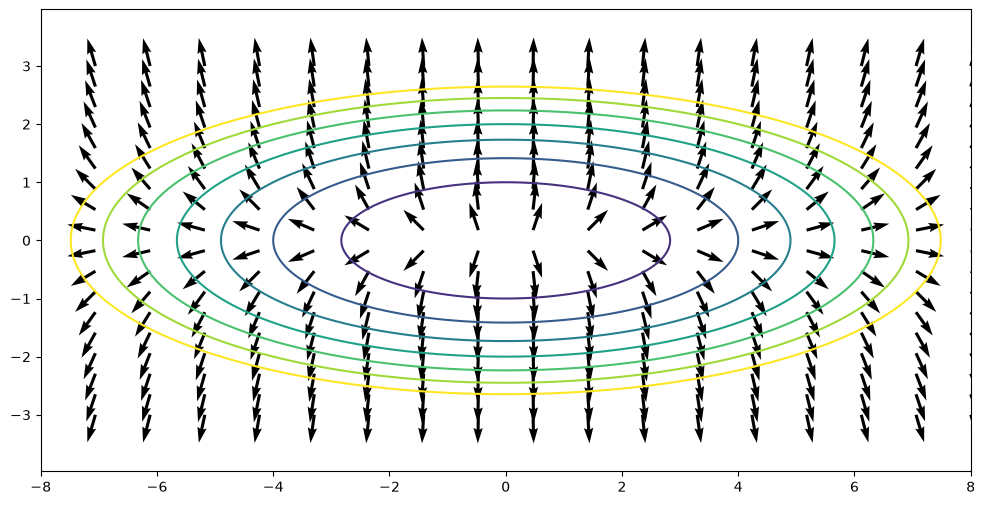

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

def draw_vector_field(F, xmin, xmax, ymin, ymax, N=20):
    X = np.linspace(xmin, xmax, N)  # X and Y coordinates
    Y = np.linspace(ymin, ymax, N)  # of the grid points
    U, V = F(*np.meshgrid(X, Y))  # vector field
    M = np.hypot(U, V)  # Norms of (U[i],V[i])
    M[M == 0] = 1  # avoids division by 0
    U /= M  # Normalize U
    V /= M  # ... and V
    return plt.quiver(X, Y, U, V, angles='xy')

def level_lines(f, xmin, xmax, ymin, ymax, levels, N=500):
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    z = f(*np.meshgrid(x, y))
    level_l = plt.contour(x, y, z, levels=levels)
    #plt.clabel(level_l, levels, fmt='%.1f') 


g = lambda x, y: .5*(x**2 + 8*y**2)
G = lambda x, y: np.array([x, 8*y])
%matplotlib inline
plt.figure(figsize=(12,6))
level_lines(g, -8, 8, -3, 3, np.linspace(0, 28, 8))
draw_vector_field(G,  -8, 8, -3, 3, 18)
plt.axis('equal')
plt.show()

**Question 8.** Implement gradient descent with optimal step. The initial point must be $x^0=\binom1C$.

**Question 9.** On the same plot, show the iterates, a few level lines of $f$ and the normalized vector field $\dfrac {1}{|\nabla f|}\nabla f$. 

In [2]:
# Solution 8 (descent algorithm)

# Parameters
eps, iter_max =1e-8, 50 
C=4
A=np.array([[C,0],[0,1]])

# Initialization
x = np.array([1, C])
g = A@x
n = np.linalg.norm(g)
it, n0, X = 0, n, [x]

# Optimization loop
while n>eps*n0 and it<iter_max :
    alpha = g.dot(g)/g.dot(A@g)   # optimal step
    x = x - alpha*g               # new iterate
    g = A@x                       # gradient
    n = np.linalg.norm(g)         # gradient norm
    it += 1    
    X.append(x)     # store the iterates

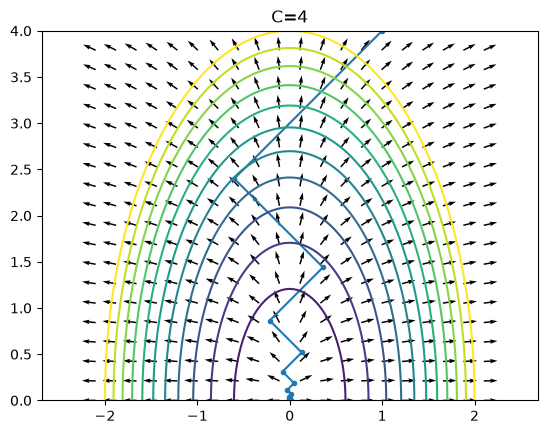

In [3]:
# Solution 9 (plots)
X=np.array(X)
f= lambda a,b: .5*(C*a**2 + b**2)
df = lambda x,y: np.array([C*x,y])
plt.figure()
plt.plot(X[:,0],X[:,1],'.',linestyle='-')
level_lines(f, -2.1, 2.1, 0, C, np.linspace(0, .5*C**2, 12))
draw_vector_field(df,   -2.1, 2.1, 0, C, 20)
plt.axis('equal')
plt.title("C="+str(C))
plt.show()

**Question 10.** Change the value of $C$ from 1 to 32 ($C=1,2,4,8,16,32$). What do you observe?

**Question 11.** Plot the number of iterations of the method as a function of $C$. Make a hypothesis. 

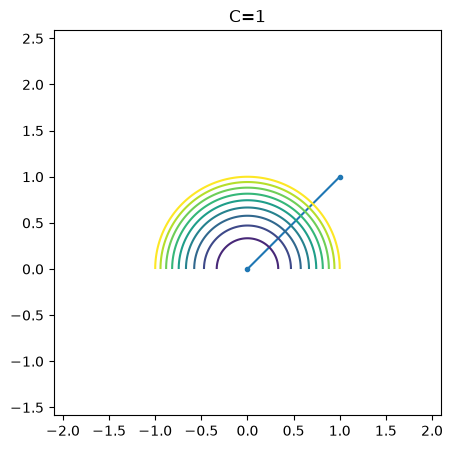

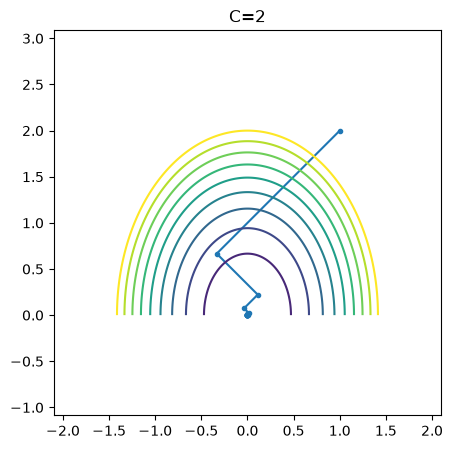

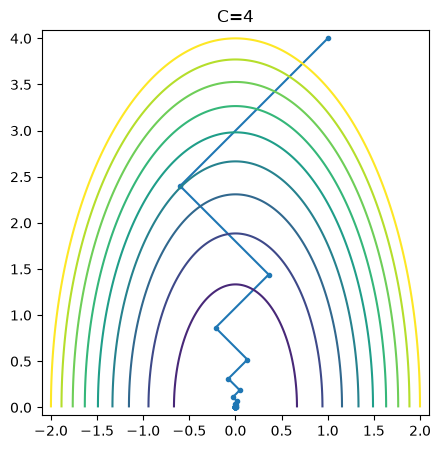

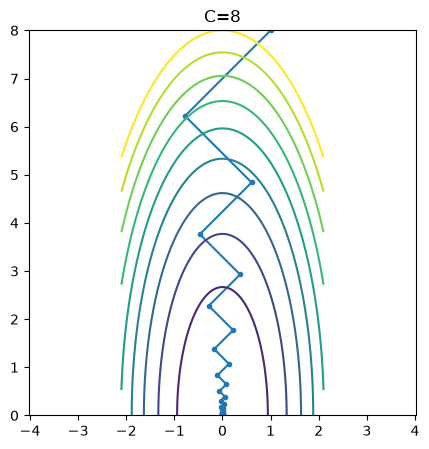

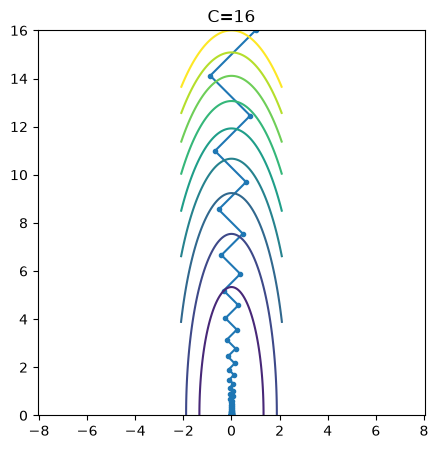

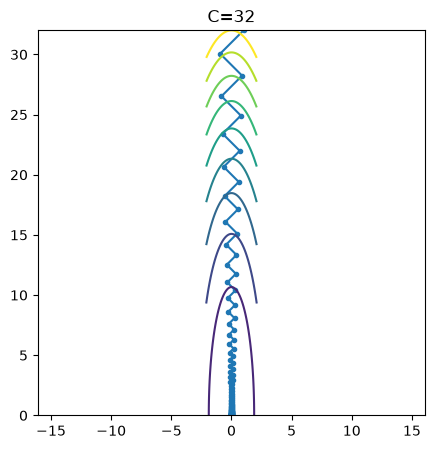

In [4]:
# Solution 10 (computations)

tab_C=(1,2,4,8,16,32)
tab_it=np.zeros(6)
epsilon = 1e-8  # error tolerance
iter_max = 1000

for j in range(6):
    C=tab_C[j]
    A=np.array([[C,0],[0,1]])
    x = np.array([1, C])
    g = A@x
    fx = .5*g.dot(x)
    n = np.linalg.norm(g)
    it, n0, X, F = 0, n, [x], [fx]    
    ## Optimization loop
    while n>eps*n0 and it<iter_max :
        alpha = g.dot(g)/g.dot(A@g)   # optimal step
        x = x - alpha*g               # new iterate
        g = A@x                       # gradient
        n = np.linalg.norm(g)         # gradient norm
        fx = .5*g.dot(x)
        it += 1    
        X.append(x) ; F.append(fx)     # store the iterates
    tab_it[j]=it
    ## Plots
    X, F = np.array(X), np.array(F)    
    plt.figure(figsize=(5,5))
    plt.plot(X[:,0],X[:,1],'.',linestyle='-')
    f, df = lambda x,y: .5*(C*x**2 + y**2), lambda x,y: np.array([C*x,y]) 
    level_lines(f, -2.1, 2.1, 0, C, np.linspace(0, .5*C**2, 10))
    #draw_vector_field(df, C,  -2.1, 2.1, 0, C, 20)
    plt.axis('equal')
    plt.title("C="+str(C))
    plt.show()
    
    # Plot of the values of f along the iterations
    #plt.figure(figsize=(5,5))
    #plt.semilogy(range(len(F)),F,'.')
    #plt.show()

__Solution 11.__ (Hypothesis on the behavior of the method.) The number of iterations needed to converge grows linearly with $C$, i.e. with the condition number of $A$.

## 2. A smooth convex function: line search

Consider the function defined by
$$
f(x,y):= \cosh(x) + \sin^2(x+y),\qquad \text{for }z=(x,y)\in \mathbb{R}^2.
$$

**Question 12.** Show that the minimizers of $f$ are the points of the form $(0,n\pi)$ for $n\in\mathbb{Z}$.

Show that $f$ is convex in a neighborhood of $z^0_*:=(0,0)$.

__Solution 12.__ Since $\cosh(x)\ge1$ and the second term is a square, hence non-negative, $f(x,y)\ge 1$ for all $(x,y)\in\mathbb{R}^2$.

Moreover 
$$
f(x,y)=1\ \iff\ \cosh(x)=1\text{ and }\sin^2(x+y)=0 \ \iff x=0\text{ and }y\in\pi\mathbb{Z}.
$$

We compute 
$$
\nabla f(x,y)=\binom{\sinh(x) + \sin(2(x+y))}{ \sin(2(x+y))}, 
$$
then 
$$
H_f(x,y)=\begin{pmatrix}\cosh(x) + 2\cos(2(x+y))&2\cos(2(x+y))\\ 2\cos(2(x+y)) &2\cos(2(x+y))\end{pmatrix}.
$$
In particular, 
$$
H_f(z^*)=\begin{pmatrix}3&2\\ 2&2\end{pmatrix}.
$$
Let $\lambda_1,\lambda_2$ be the eigenvalues of $S:=H_f(0,0)$. Then $\lambda_1\lambda_2=\det S=2>0$ and $\lambda_1+
\lambda_2=\mathrm{Tr}(S)=5>0$, so $\lambda_1,\lambda_2>0$ and $S$ is positive definite. We conclude that $z^*$ is a minimum point of $f$.

The Hessian depends continuously on $(x,y)$: its strict positivity at $(0,0)$ still holds in a small enough neighborhood, which proves **local** convexity. The function is not globally convex.


We now apply gradient descent with *line search* to $f$. More precisely:

Given $z^0=(x^0,y^0)\in\mathbb{R}^2$, compute recursively, until convergence,

$$
\left|
\begin{array}{lcl}
d^k& \longleftarrow & -\nabla f(z^k),\\
\alpha_k &\longleftarrow & \text{Line-search}\ \left(\ t\mapsto f(z^k + td^k)\ \right),\\ 
z^{k+1}&\longleftarrow &z^k+\alpha_k d^k
\end{array}
\right.
$$

Let us detail the second step. First note that for $t>0$,

$$
f(z^k+t d^k) \,=\, f(z^k) -t \|d^k\|^2 +o(t).
$$

In fact, if $f$ is convex in a neighborhood of $z^k$, we also have, for small enough $t>0$, 

$$
f(z^k+t d^k)\, \ge\, f(z^k) -t \|d^k\|^2,
$$

so we cannot require $f(z^k+t d^k) \,\le\, f(z^k) -t \|d^k\|^2$. 

The idea of the *Armijo condition* is to require slightly less. Fix $c\in (0,1)$; the Armijo condition reads: 

$$
\tag{2}f(z^k+t d^k)\, \le\, f(z^k) -c\, t \|d^k\|^2.
$$

Using the Taylor expansion above, 

$$
\begin{array}{rcl}
f(z^k+t d^k) &=& f(z^k) -t \|d^k\|^2 +o(t)\\
   &=& f(z^k) -c\, t \|d^k\|^2 - (1-c)t\|d^k\|^2 +o(t)\\
   & = & f(z^k) -c\, t \|d^k\|^2 -t \left[(1-c)\|d^k\|^2 +o(1)\right]
\end{array}
$$

For small enough $t>0$, the bracketed term is positive, so (2) holds.

However, we do not want $\alpha_k$ to be too small (the algorithm would stall). To avoid this, we fix a maximum step $\alpha_0$ and a factor $\beta\in(0,1)$, and successively test (2) with $t=\alpha_0$, $t=\alpha_0\beta$, $t=\alpha_0\beta^2$, ... 

We choose $\alpha_k=\alpha_0\beta^j$, where $j$ is the first integer such that $t=\alpha_0\beta^j$ satisfies (2).

Since $0<\beta<1$ and (2) holds for small enough $t>0$, this integer exists. 

**Question 13.** Implement the method above with $c=0.5$, $\beta=0.75$. Start from $z^0=(1,0.5)$ and $\alpha=1$. Then, for $k\ge 1$, use $\alpha\leftarrow\alpha_{k-1}/\beta$.

To help, the next cell shows a few level sets of $f$ and the normalized vector field $\dfrac {1}{|\nabla f|}\nabla f$ near $z^*$. 

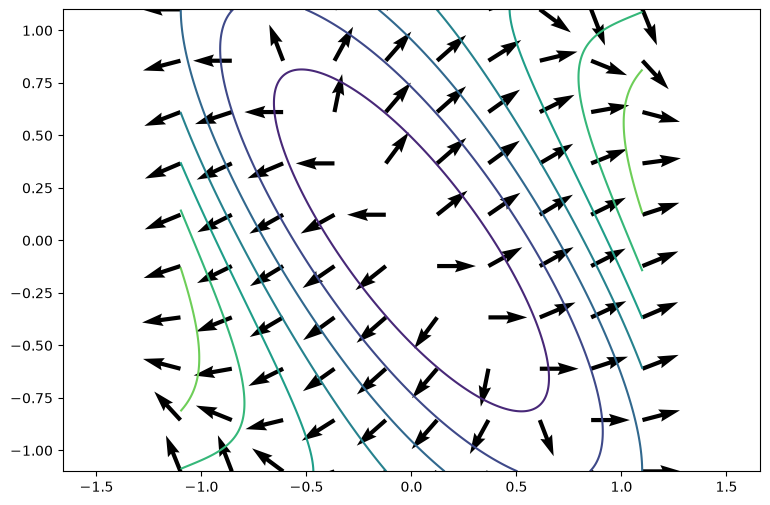

In [5]:
def draw_vector_field_2(F, xmin, xmax, ymin, ymax, N=15):
    X = np.linspace(xmin, xmax, N)  
    Y = np.linspace(ymin, ymax, N)
    U, V = F(*np.meshgrid(X, Y))  # Vector field
    M = np.hypot(U, V)  # Norms of (U[i],V[i])
    M[M == 0] = 1  # avoids division by 0
    U /= M  # normalize U
    V /= M  # ... and V
    return plt.quiver(X, Y, U, V, angles='xy')

def level_lines_2(f, xmin, xmax, ymin, ymax, levels, N=500):
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    z = f(*np.meshgrid(x, y))
    level_l = plt.contour(x, y, z, levels=levels)
    #plt.clabel(level_l, levels, fmt='%.1f') 

f = lambda x, y : np.cosh(x)+ np.sin(x + y)**2
df = lambda x, y : np.array([np.sinh(x) 
                             + 2*np.cos(x + y)*np.sin(x + y),
                             2*np.cos(x + y)*np.sin(x + y)])
%matplotlib inline
plt.figure(figsize=(9,6))
level_lines_2(f, -1.1, 1.1, -1.1, 1.1, np.linspace(1, 3, 10))
draw_vector_field_2(df, -1.1, 1.1, -1.1, 1.1, 10)
plt.axis('equal')
plt.show()

In [6]:
# Definition of f and df (i.e. f')
f = lambda x, y : np.cosh(x)+ np.sin(x + y)**2
df = lambda x, y : np.array([np.sinh(x) + 2*np.cos(x + y)*np.sin(x + y), 2*np.cos(x + y)*np.sin(x + y)])

flag = OK, n_iter = 60


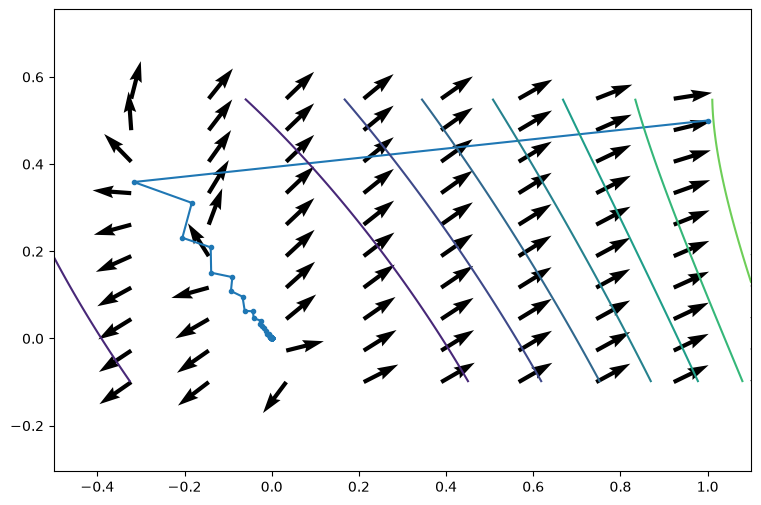

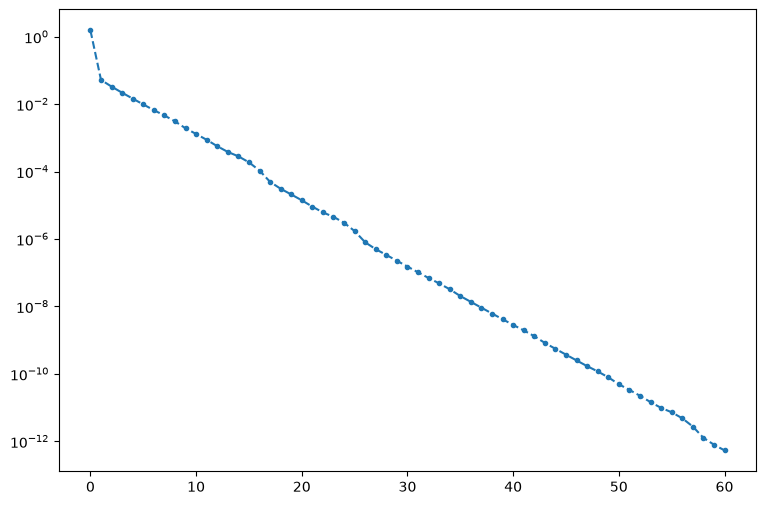

number of iterations: 60


In [7]:
# Solution 13

## Parameters
epsilon = 1e-6
c, beta = 0.5, 0.75
itermax = 500
iter_ls_max = 20
## Initialization
iter = 0
x, y, alpha = 1., .5, 1. 
fz = f(x,y)
Z, F =[np.array([x, y])], [fz]
flag = 'OK'

## Optimization loop
while (iter < itermax):
    dx, dy = -df(x, y)
    d = np.hypot(dx, dy)
    if d < epsilon or flag == 'Not OK':
        break
    dd =d**2
    new_fz = f(x + alpha*dx, y + alpha*dy) 
    iter_ls = 0
    while (new_fz - fz + c*alpha*dd >=0):
        alpha *= beta
        new_fz = f(x + alpha*dx, y + alpha*dy)
        iter_ls += 1
        if (iter_ls>=iter_ls_max):
            flag = 'Not OK'
            break
    #print("d = " + str(d) + ", f(z) - 1 =" + str(fz-1) + ", t= " +str(t))
    x, y, fz = x + alpha*dx, y + alpha*dy, new_fz
    Z.append(np.array([x, y]))
    F.append(fz)
    alpha /= beta
    iter += 1

print('flag = '+flag + ', n_iter = ' + str(iter))    
    
Z = np.array(Z)
F = np.array(F)

# Plots
plt.figure(figsize=(9,6))
plt.plot(Z[:,0],Z[:,1],'.',linestyle='-')
level_lines_2(f, -0.5, 1.1, -0.1, 0.55, np.linspace(1, 3, 10))
draw_vector_field_2(df, -0.5, 1.1, -0.1, 0.55, 10)
plt.axis('equal')
plt.show()

# Values of f along the iterations.
plt.figure(figsize=(9,6))
plt.semilogy(range(len(F)),F-1,'.',linestyle='dashed')
plt.show()

print("number of iterations:", iter)

We now consider the function defined on $\mathbb{R}^3$ by 
$$
f(x,y,z):= \cosh(x) + \sin^2(x+y) + (y-z)^2,\qquad \text{for }w=(x,y,z)\in \mathbb{R}^3.
$$

**Question 14.** Apply the optimization method above to this function, starting from $w^0=(1,0.5,1)$ (still with $c=0.5$, $\beta=0.75$ and $\alpha=1$ at the first iteration). 

In [8]:
# Definition of f and df (i.e. f')
f = lambda w : np.cosh(
    w[0])+ np.sin(w[0] + w[1])**2 + (w[1] - w[2])**2
df = lambda w : np.array(
    [np.sinh(w[0]) + 2*np.cos(w[0] + w[1])*np.sin(w[0] + w[1]), 
     2*np.cos(w[0] + w[1])*np.sin(w[0] + w[1]) + 2*(w[1] - w[2]), 
     2*(w[2] - w[1])])

flag = OK, n_iter = 148, itermax = 200


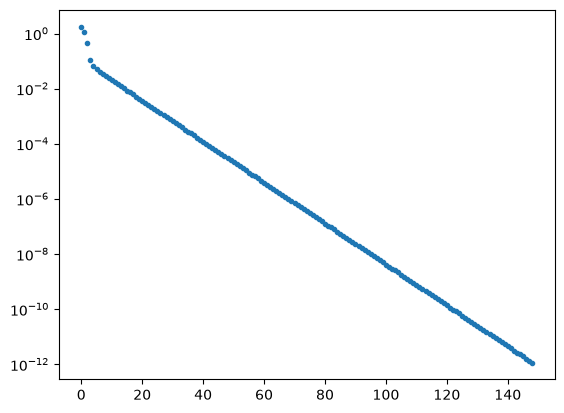

In [9]:
# Solution 14 
## Parameters
epsilon = 1e-6
c, beta = 0.5, 0.75
itermax = 200
iter_ls_max =30

## Initialization
iter = 0
w, alpha = np.array([1., .5, 1.]) , 1.
fw = f(w)
W, F =[w], [fw]
flag = 'OK'

## Optimization loop
while (iter < itermax):
    d = -df(w)
    norm_d = np.linalg.norm(d)
    if norm_d < epsilon or flag == 'Not OK':
        break
    dd =norm_d**2
    new_fw = f(w + alpha*d)
    iter_ls = 0
    while (new_fw - fw + c*alpha*dd >=0):
        alpha *= beta
        new_fw = f(w + alpha*d) 
        iter_ls += 1
        if (iter_ls>=iter_ls_max):
            flag = 'Not OK'
            break
    #print("norm_d = " + str(norm_d) + ", f(w) - 1 =" + str(fw-1) + ", t= " +str(t))
    w, fw = w + alpha*d, new_fw
    alpha /= beta
    W.append(w)
    F.append(fw)
    iter += 1

print('flag = '+flag + ', n_iter = ' + str(iter) + ', itermax = ' + str(itermax))   


# Values of f along the iterations
F = np.array(F)
plt.figure()
plt.semilogy(range(len(F)), F-1, '.')
plt.show()